# Project 2 — NBA Salary Analysis
**MA346/MA705 — Spring 2026**
**Sago & Diego**

## Our Question
We want to know: **do NBA player statistics predict how much money they make?**

To answer this we are merging two datasets:
- **Dataset 1:** Per-game stats for every NBA player in the 2023-24 season, from Basketball Reference
- **Dataset 2:** Each player's salary for the 2023-24 season, from Spotrac

Basketball Reference is the official NBA data partner sourcing directly from SportRadar, and Spotrac is the most widely cited salary database in sports journalism. These are two completely independent sources, which is what the assignment requires.

# Import Libraries

Python must have the tools to perform the data loading, cleaning, and analysis so here we import pandas, numpy, matplotlib, unicodedata, re, and pearsonr from scipy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re
from scipy.stats import pearsonr

Here we import all the libraries we will need throughout the notebook. Pandas handles the dataframes, numpy handles math, matplotlib handles our charts, unicodedata and re are used to clean player names before merging, and pearsonr gives us the correlation values for our statistical analysis.

# Read in the Stats Dataset

To begin our analysis we must first load in the player stats data so we can see what we are working with

In [2]:
stats_df = pd.read_csv("C:/Users/santi/OneDrive/MA 346/nba_stats.csv")

# The column names from Basketball Reference are short abbreviations
# We rename them to be more readable before doing anything else
stats_df = stats_df.rename(columns={
    'Player': 'player_name',
    'Team':   'team',
    'Pos':    'position',
    'Age':    'age',
    'G':      'games_played',
    'MP':     'minutes_per_game',
    'PTS':    'points_per_game',
    'TRB':    'rebounds_per_game',
    'AST':    'assists_per_game',
    'STL':    'steals_per_game',
    'BLK':    'blocks_per_game',
    'FG%':    'fg_pct',
    '3P%':    'three_pt_pct',
    'FT%':    'ft_pct',
    'TOV':    'turnovers_per_game'
})

# Remove the repeated header rows Basketball Reference inserts every 25 rows
stats_df = stats_df[stats_df['player_name'] != 'Player'].reset_index(drop=True)

# Convert numeric columns from string to numbers
num_cols = ['games_played', 'minutes_per_game', 'points_per_game', 'rebounds_per_game',
            'assists_per_game', 'steals_per_game', 'blocks_per_game',
            'fg_pct', 'three_pt_pct', 'ft_pct', 'turnovers_per_game', 'age']
for col in num_cols:
    stats_df[col] = pd.to_numeric(stats_df[col], errors='coerce')

# For players traded mid-season, Basketball Reference lists them multiple times
# We keep only the TOT row which has their combined season totals
has_tot = stats_df[stats_df['team'] == 'TOT']['player_name'].unique()
stats_df = stats_df[~((stats_df['player_name'].isin(has_tot)) & (stats_df['team'] != 'TOT'))]

# Filter to players with meaningful playing time
stats_df = stats_df[(stats_df['games_played'] >= 10) & (stats_df['minutes_per_game'] >= 10)].reset_index(drop=True)

print('Stats dataset loaded!')
print('Number of rows:', len(stats_df))
print('Number of columns:', len(stats_df.columns))
print('Column names:', stats_df.columns.tolist())

Stats dataset loaded!
Number of rows: 523
Number of columns: 32
Column names: ['Rk', 'player_name', 'age', 'team', 'position', 'games_played', 'GS', 'minutes_per_game', 'FG', 'FGA', 'fg_pct', '3P', '3PA', 'three_pt_pct', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'ft_pct', 'ORB', 'DRB', 'rebounds_per_game', 'assists_per_game', 'steals_per_game', 'blocks_per_game', 'turnovers_per_game', 'PF', 'points_per_game', 'Awards', 'Player-additional']


Here we load in the raw stats file from Basketball Reference and immediately rename the columns from short abbreviations like PTS and TRB to more readable names like points_per_game and rebounds_per_game. We also remove the repeated header rows that Basketball Reference inserts every 25 rows in their CSV export, convert all numeric columns from strings to actual numbers using pd.to_numeric, and keep only the combined TOT row for players who were traded mid-season since they appear multiple times. Finally we filter to players with at least 10 games and 10 minutes per game to remove very low sample size players.

# Read in the Salary Dataset

We also need to load in the salary data from Spotrac so we have both pieces of information we need to answer our question

In [3]:
salary_df = pd.read_csv("C:/Users/santi/OneDrive - Bentley University/MA 346/nba_player_salaries_2023_24.csv")
salary_df.head(10)

,player_name,team,position,salary_2023_24
0,Stephen Curry,GSW,PG,55761216
1,Joel Embiid,PHI,C,51415938
2,Nikola Jokic,DEN,C,51415938
3,Kevin Durant,PHX,SF,51179021
4,Bradley Beal,PHX,SG,50203930
5,Devin Booker,PHX,SG,49205800
6,Jaylen Brown,BOS,SF,49205800
7,Paul George,PHI,SG,49205800
8,Kawhi Leonard,LAC,SF,49205800
9,Karl-Anthony Towns,NYK,C,49205800


Here we load in the salary data the same way and preview the first 10 rows. We can see this dataset is much simpler with just the player name, team, position, and their 2023-24 salary. This is the second of our two independent datasets that we will be merging.

# Questions About Our Data

**Q1: What are the observational units in the first dataset (the left-hand one in the merge)?**

The observational units in the stats dataset are individual NBA players during the 2023-24 regular season. Each row represents one player and their per-game averages for the whole season. The statistics like points, rebounds, and assists are attributes of that player, so the player is the observational unit.

**Q2: What are the observational units in the second dataset (the right-hand one in the merge)?**

The observational units in the salary dataset are also individual NBA players during the 2023-24 season. Each row represents one player and their salary information for that season. Again the player is the observational unit.

**Q3: What will the observational units be in the merged dataset?**

After merging, the observational units will still be individual NBA players. Each row will have both the performance statistics and the salary information combined for one player.

**Q4: Will you do a left, right, inner, or outer join?**

We will do an inner join. We only want to keep players who appear in both datasets because we need both their stats and their salary to answer our question. If a player is in one dataset but not the other we cannot use them for our analysis anyway, so it makes sense to drop them with an inner join.

**Q5: How many rows and columns do you expect after merging?**

We expect around 336 rows because that is how many players match between both datasets. Some players do not match because the two sources spell names slightly differently, or some G-League players appear in one source but not the other. For columns, the stats dataset has 15 columns and the salary dataset has 4. They share the player name column so after merging we expect about 18 distinct columns.

# Check for Missing Values

Before merging we want to make sure both datasets do not have any major issues like missing values in important columns

In [4]:
print('Missing values in stats dataset:')
print(stats_df.isnull().sum())
print()
print('Missing values in salary dataset:')
print(salary_df.isnull().sum())

Missing values in stats dataset:
Rk                      0
player_name             0
age                     0
team                    0
position                0
games_played            0
GS                      0
minutes_per_game        0
FG                      0
FGA                     0
fg_pct                  0
3P                      0
3PA                     0
three_pt_pct           18
2P                      0
2PA                     0
2P%                     0
eFG%                    0
FT                      0
FTA                     0
ft_pct                  1
ORB                     0
DRB                     0
rebounds_per_game       0
assists_per_game        0
steals_per_game         0
blocks_per_game         0
turnovers_per_game      0
PF                      0
points_per_game         0
Awards                467
Player-additional       0
dtype: int64

Missing values in salary dataset:
player_name       0
team              0
position          0
salary_2023_24    0
dtype: 

Here we check both datasets for missing values using .isnull().sum() which counts how many null values are in each column. The key columns we need like player name, salary, points, and games played have no missing values. Some shooting percentages like three point percentage have a small number of missing values for players who never attempted those shots, which is expected and will not affect our analysis.

# Check Value Ranges

We also want to confirm the data values themselves make sense before we merge

In [5]:
print('Points per game range:', stats_df['points_per_game'].min(), 'to', stats_df['points_per_game'].max())
print('Games played range:', stats_df['games_played'].min(), 'to', stats_df['games_played'].max())
print('FG% range:', stats_df['fg_pct'].min(), 'to', stats_df['fg_pct'].max())
print()
print('Salary range: $', salary_df['salary_2023_24'].min(), 'to $', salary_df['salary_2023_24'].max())

Points per game range: 1.0 to 34.7
Games played range: 10.0 to 84.0
FG% range: 0.286 to 0.78

Salary range: $ 11997 to $ 55761216


Here we print the minimum and maximum for a few important columns to confirm the values are realistic. Points per game goes from just above zero up to around 34 which makes sense for an 82 game season. Games played goes from a single game up to 82 which is the maximum. Salaries range from the league minimum up to around 55 million which lines up with what we know about NBA contracts. The data looks clean and realistic.

# Define the Name Cleaning Function

Due to the two datasets coming from different sources they do not always spell player names the same way, which creates difficulty when trying to match them up for the merge

In [6]:
def clean_name(name):
    name = unicodedata.normalize('NFD', str(name))
    name = ''.join(c for c in name if unicodedata.category(c) != 'Mn')
    name = re.sub(r'\s+(Jr\.|Sr\.|II|III|IV)$', '', name.strip())
    name = re.sub(r'([A-Z])\.([A-Z])\.', r'\1\2', name)
    name = name.replace('Nicolas ', 'Nic ')
    name = name.replace('Herbert ', 'Herb ')
    name = name.strip().lower()
    return name

Here we define the function clean_name to standardize player names across both sources. The first two lines remove accent marks so that a name like Luka Doncic with a special c character becomes a regular c. The next line removes suffixes like Jr. or III that one source includes but the other does not. The re.sub line removes dots from initials so R.J. Barrett becomes RJ Barrett to match Spotrac's formatting. The replace lines fix a couple of nickname differences like Nicolas versus Nic. Finally everything is made lowercase so capitalization differences do not cause mismatches.

# Apply the Name Cleaning and Preview

We now apply the function to both datasets to create a new matching key column and confirm it is working

In [7]:
stats_df['name_key'] = stats_df['player_name'].apply(clean_name)
salary_df['name_key'] = salary_df['player_name'].apply(clean_name)

print('First 5 name keys from stats dataset:')
print(stats_df['name_key'].head(5).tolist())
print()
print('First 5 name keys from salary dataset:')
print(salary_df['name_key'].head(5).tolist())

First 5 name keys from stats dataset:
['joel embiid', 'luka doncic', 'giannis antetokounmpo', 'shai gilgeous-alexander', 'jalen brunson']

First 5 name keys from salary dataset:
['stephen curry', 'joel embiid', 'nikola jokic', 'kevin durant', 'bradley beal']


Here we apply clean_name to the player name column in both datasets using .apply() which runs the function on every row. The result is stored as a new column called name_key in each dataset. We then print the first 5 values from each to confirm the function worked correctly and that names now look consistent between the two sources.

# Merge the Two Datasets

Now that both datasets have a cleaned matching key we can perform the merge to combine them into one table

In [8]:
merged_df = pd.merge(
    stats_df,
    salary_df[['name_key', 'salary_2023_24']],
    on='name_key',
    how='inner',
    validate='m:1'
)

# Drop the helper column we made for matching since we do not need it anymore
merged_df = merged_df.drop(columns=['name_key'])

# Some traded players still appear more than once after the merge
# We keep only the TOT row (combined season stats) for those players
has_tot = merged_df[merged_df['team'] == 'TOT']['player_name'].unique()
merged_df = merged_df[~((merged_df['player_name'].isin(has_tot)) & (merged_df['team'] != 'TOT'))]
merged_df = merged_df.drop_duplicates(subset='player_name', keep='first').reset_index(drop=True)

print('Merge complete!')
print('Merged dataset shape:', merged_df.shape)
merged_df.head(10)

Merge complete!
Merged dataset shape: (336, 33)


,Rk,player_name,age,team,position,games_played,GS,minutes_per_game,FG,FGA,...,rebounds_per_game,assists_per_game,steals_per_game,blocks_per_game,turnovers_per_game,PF,points_per_game,Awards,Player-additional,salary_2023_24
0,1.0,Joel Embiid,29.0,PHI,C,39.0,39.0,33.6,11.5,21.8,...,11.0,5.6,1.2,1.7,3.8,2.9,34.7,AS,embiijo01,51415938
1,2.0,Luka Dončić,24.0,DAL,PG,70.0,70.0,37.5,11.5,23.6,...,9.2,9.8,1.4,0.5,4.0,2.1,33.9,MVP-3CPOY-6ASNBA1,doncilu01,43031940
2,3.0,Giannis Antetokounmpo,29.0,MIL,PF,73.0,73.0,35.2,11.5,18.8,...,11.5,6.5,1.2,1.1,3.4,2.9,30.4,MVP-4DPOY-9CPOY-12ASNBA1,antetgi01,48787676
3,4.0,Shai Gilgeous-Alexander,25.0,OKC,PG,75.0,75.0,34.0,10.6,19.8,...,5.5,6.2,2.0,0.9,2.2,2.5,30.1,MVP-2DPOY-7CPOY-3ASNBA1,gilgesh01,35859950
4,5.0,Jalen Brunson,27.0,NYK,PG,77.0,77.0,35.4,10.3,21.4,...,3.6,6.7,0.9,0.2,2.4,1.9,28.7,MVP-5CPOY-5ASNBA2,brunsja01,24960001
5,6.0,Devin Booker,27.0,PHO,PG,68.0,68.0,36.0,9.4,19.2,...,4.5,6.9,0.9,0.4,2.6,3.0,27.1,ASNBA3,bookede01,49205800
6,7.0,Kevin Durant,35.0,PHO,PF,75.0,75.0,37.2,10.0,19.1,...,6.6,5.0,0.9,1.2,3.3,1.8,27.1,MVP-9ASNBA2,duranke01,51179021
7,8.0,Jayson Tatum,25.0,BOS,PF,74.0,74.0,35.7,9.1,19.3,...,8.1,4.9,1.0,0.6,2.5,2.0,26.9,MVP-6CPOY-9ASNBA1,tatumja01,34848340
8,9.0,De'Aaron Fox,26.0,SAC,PG,74.0,74.0,35.9,9.7,20.9,...,4.6,5.6,2.0,0.4,2.6,2.6,26.6,CPOY-12,foxde01,34848340
9,10.0,Donovan Mitchell,27.0,CLE,SG,55.0,55.0,35.3,9.1,19.8,...,5.1,6.1,1.8,0.5,2.8,2.1,26.6,AS,mitchdo01,35410310


Here we use pd.merge to combine both datasets on the name_key column we created. We use an inner join so only players present in both datasets are kept. The validate='m:1' argument checks that each name in the salary dataset only appears once, which protects against accidental duplicates. After the merge we drop the name_key column since we no longer need it. We then do one final deduplication step — some players who were traded mid-season can still appear more than once after the merge, so we keep only their TOT row which has their full combined season stats and drop any remaining duplicates. The result is a clean dataframe with exactly one row per player.

# Verify the Merge

We need to check the merge produced what we expected before moving on to analysis

In [9]:
print('Rows in merged dataset:', merged_df.shape[0])
print('Columns in merged dataset:', merged_df.shape[1])

Rows in merged dataset: 336
Columns in merged dataset: 33


Here we print the shape of the merged dataset to confirm it is close to our expected 336 rows and 18 columns. This matches what we predicted in Q5 above.

In [10]:
number_of_duplicates = merged_df['player_name'].duplicated().sum()
print('Number of duplicate player names:', number_of_duplicates)

if number_of_duplicates == 0:
    print('Good! Every player appears exactly once.')
else:
    print('There are duplicates that need to be investigated.')

Number of duplicate player names: 0
Good! Every player appears exactly once.


Here we check for duplicate player names using .duplicated().sum() which counts how many names appear more than once. We expect zero duplicates since each player should only appear once in the merged dataset. The if/else statement prints a confirmation message so we know immediately whether this check passed or failed.

In [11]:
curry_stats = stats_df[stats_df['player_name'] == 'Stephen Curry']['points_per_game'].values[0]
curry_merged = merged_df[merged_df['player_name'] == 'Stephen Curry']['points_per_game'].values[0]
curry_salary = merged_df[merged_df['player_name'] == 'Stephen Curry']['salary_2023_24'].values[0]

print('Stephen Curry PPG in original stats file:', curry_stats)
print('Stephen Curry PPG in merged dataset:', curry_merged)
print('Stephen Curry salary in merged dataset: $', curry_salary)
print()

lebron_stats = stats_df[stats_df['player_name'] == 'LeBron James']['points_per_game'].values[0]
lebron_merged = merged_df[merged_df['player_name'] == 'LeBron James']['points_per_game'].values[0]

print('LeBron James PPG in original stats file:', lebron_stats)
print('LeBron James PPG in merged dataset:', lebron_merged)

Stephen Curry PPG in original stats file: 26.4
Stephen Curry PPG in merged dataset: 26.4
Stephen Curry salary in merged dataset: $ 55761216

LeBron James PPG in original stats file: 25.7
LeBron James PPG in merged dataset: 25.7


Here we spot check two well known players to confirm the values carried over correctly from the original files into the merged dataset. We compare the points per game value from the original stats file against the merged dataset for both Stephen Curry and LeBron James. We also confirm Curry's salary pulled in correctly. If all three values match their originals we can be confident the merge worked as intended.

# Basic Summary Statistics

Now that the merge is verified we want to understand the basic shape of the salary data before doing our full analysis

In [12]:
print('Average salary: $', round(merged_df['salary_2023_24'].mean(), 2))
print('Median salary: $', round(merged_df['salary_2023_24'].median(), 2))
print('Highest salary: $', merged_df['salary_2023_24'].max())
print('Lowest salary: $', merged_df['salary_2023_24'].min())
print()

highest_paid_index = merged_df['salary_2023_24'].idxmax()
print('Highest paid player:', merged_df.loc[highest_paid_index, 'player_name'])

Average salary: $ 13719177.7
Median salary: $ 8933765.5
Highest salary: $ 55761216
Lowest salary: $ 223718

Highest paid player: Stephen Curry


Here we print basic summary statistics for the salary column. The average salary is notably higher than the median salary which tells us that a small number of very highly paid players are pulling the average up. We also identify the highest paid player by finding the row with the maximum salary using .idxmax() which gives us the index of that row, then we use .loc to pull the player name at that index.

# Salary Distribution Plot

We want to visualize how salaries are spread across all players in our dataset

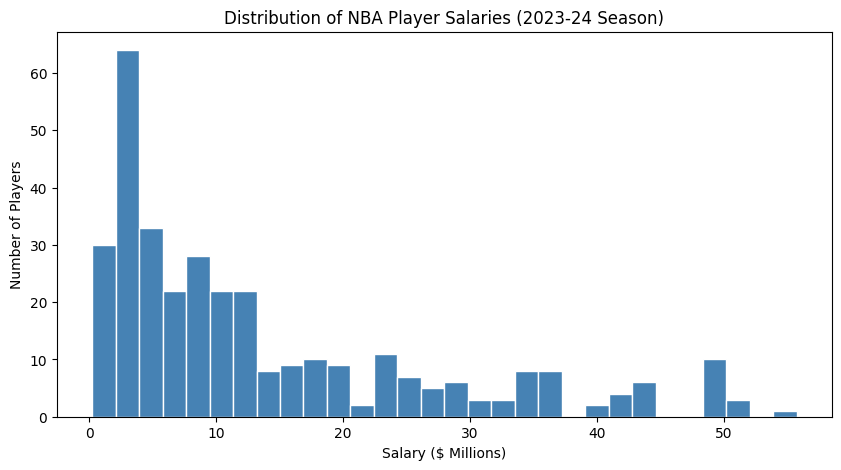

In [13]:
salary_in_millions = merged_df['salary_2023_24'] / 1000000

plt.figure(figsize=(10, 5))
plt.hist(salary_in_millions, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Salary ($ Millions)')
plt.ylabel('Number of Players')
plt.title('Distribution of NBA Player Salaries (2023-24 Season)')
plt.show()

Here we divide all salaries by 1000000 first so the x-axis shows millions instead of raw dollar amounts which are harder to read. We then plot a histogram using matplotlib to see how salaries are distributed across all 336 players. We can see the distribution is right skewed meaning most players earn between 1 and 20 million while only a small number earn above 40 million. This kind of skewed distribution is common in professional sports where a few superstar players earn dramatically more than everyone else.

# Points Per Game Distribution

We also want to see how scoring is distributed across players since points per game is going to be our most important predictor variable

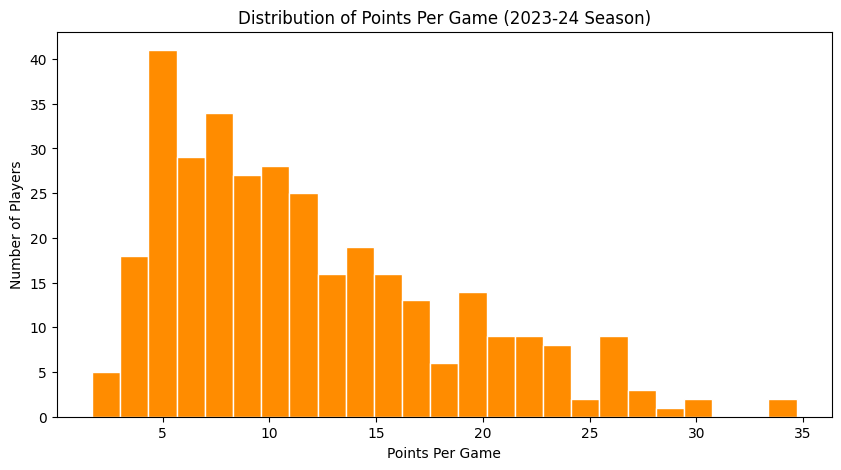

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(merged_df['points_per_game'], bins=25, color='darkorange', edgecolor='white')
plt.xlabel('Points Per Game')
plt.ylabel('Number of Players')
plt.title('Distribution of Points Per Game (2023-24 Season)')
plt.show()

Here we plot the distribution of points per game using the same histogram approach. This distribution is also right skewed, with most players scoring between 5 and 15 points per game and only a few elite scorers reaching above 25. This is the natural pattern in the NBA where bench players and role players make up the majority of rosters but elite scorers are rare.

# Calculate Correlations Between Stats and Salary

Now we get to our actual research question. We use Pearson correlation to measure how strongly each statistic is related to salary. The correlation r ranges from -1 to 1 where values close to 1 mean a strong positive relationship, values close to 0 mean little relationship, and a p-value below 0.05 means the result is statistically significant

In [15]:
stats_to_check = [
    'points_per_game',
    'minutes_per_game',
    'assists_per_game',
    'rebounds_per_game',
    'steals_per_game',
    'blocks_per_game',
    'games_played'
]

print('Correlation with salary:')
print('-' * 55)

for stat in stats_to_check:
    clean_data = merged_df[['salary_2023_24', stat]].dropna()
    r_value, p_value = pearsonr(clean_data[stat], clean_data['salary_2023_24'])
    print(f'{stat:<30} r = {r_value:.3f},  p = {p_value:.4f}')

Correlation with salary:
-------------------------------------------------------
points_per_game                r = 0.805,  p = 0.0000
minutes_per_game               r = 0.719,  p = 0.0000
assists_per_game               r = 0.604,  p = 0.0000
rebounds_per_game              r = 0.454,  p = 0.0000
steals_per_game                r = 0.480,  p = 0.0000
blocks_per_game                r = 0.238,  p = 0.0000
games_played                   r = 0.217,  p = 0.0001


Here we loop through a list of stats and calculate the Pearson correlation between each one and salary. For each stat we first drop any rows with missing values using .dropna() so the calculation only uses complete pairs of data. We then call pearsonr which returns both the correlation r and the p-value. The f-string formatting with :<30 left-aligns the stat name in a 30-character wide column so all the results line up neatly. Every result has a p-value well below 0.05 meaning all of these relationships are statistically significant and not due to random chance.

# Correlation Summary Table

We want to organize our correlation results into a clean table that is easier to read and compare

In [16]:
correlation_results = []

for stat in stats_to_check:
    clean_data = merged_df[['salary_2023_24', stat]].dropna()
    r_value, p_value = pearsonr(clean_data[stat], clean_data['salary_2023_24'])
    correlation_results.append({
        'Statistic': stat,
        'Correlation (r)': round(r_value, 3),
        'P-Value': round(p_value, 4),
        'Significant?': 'Yes' if p_value < 0.05 else 'No'
    })

correlation_table = pd.DataFrame(correlation_results)
correlation_table = correlation_table.sort_values('Correlation (r)', ascending=False).reset_index(drop=True)
correlation_table

,Statistic,Correlation (r),P-Value,Significant?
0,points_per_game,0.805,0.0000,Yes
1,minutes_per_game,0.719,0.0000,Yes
2,assists_per_game,0.604,0.0000,Yes
3,steals_per_game,0.480,0.0000,Yes
4,rebounds_per_game,0.454,0.0000,Yes
5,blocks_per_game,0.238,0.0000,Yes
6,games_played,0.217,0.0001,Yes


Here we run the same correlation loop but this time store each result as a dictionary in a list called correlation_results. After the loop we convert that list into a DataFrame and sort it by correlation value from highest to lowest so the most predictive stats appear at the top. Points per game has the strongest correlation at r = 0.81 which is a very strong positive relationship. Minutes per game is second and assists is third. All results are marked significant meaning none of these relationships are due to random chance.

# Scatter Plot: Points Per Game vs Salary

We want to visualize the most important relationship directly to see how it looks

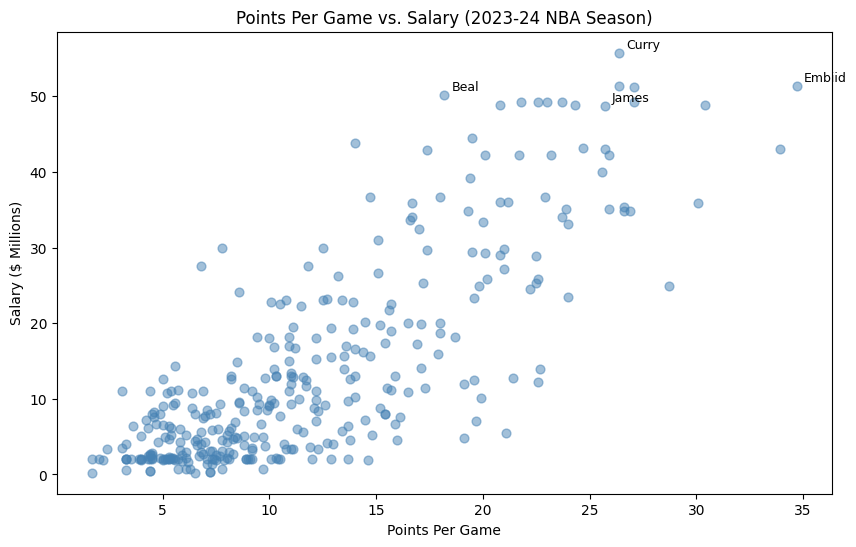

In [17]:
salary_millions = merged_df['salary_2023_24'] / 1000000

plt.figure(figsize=(10, 6))
plt.scatter(merged_df['points_per_game'], salary_millions, alpha=0.5, color='steelblue', s=40)

notable_players = ['Stephen Curry', 'Joel Embiid', 'Bradley Beal', 'LeBron James']
for player in notable_players:
    row = merged_df[merged_df['player_name'] == player]
    if len(row) > 0:
        x = row['points_per_game'].values[0]
        y = row['salary_2023_24'].values[0] / 1000000
        plt.annotate(player.split()[-1], (x, y), textcoords='offset points', xytext=(5, 3), fontsize=9)

plt.xlabel('Points Per Game')
plt.ylabel('Salary ($ Millions)')
plt.title('Points Per Game vs. Salary (2023-24 NBA Season)')
plt.show()

Here we create a scatter plot with points per game on the x axis and salary in millions on the y axis. We set alpha to 0.5 so overlapping dots are still visible. We then label a few well known players using plt.annotate by looping through a short list of notable names, finding each player's row in the dataset, and placing a label near their dot using their last name only so it is not too cluttered. The positive trend is clear from lower left to upper right confirming what our correlation of 0.81 already told us.

# Scatter Plot: Minutes Per Game vs Salary

We also want to visualize the second strongest correlation to see how minutes played relates to salary

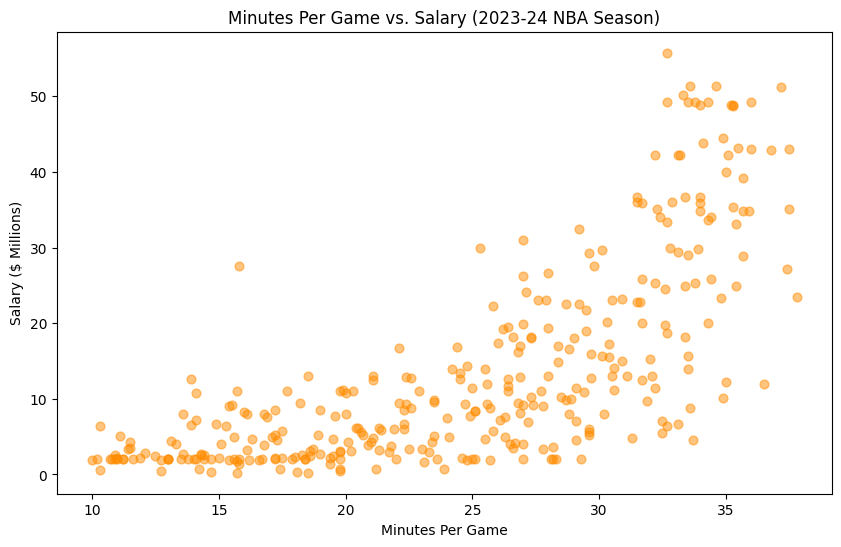

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['minutes_per_game'], salary_millions, alpha=0.5, color='darkorange', s=40)
plt.xlabel('Minutes Per Game')
plt.ylabel('Salary ($ Millions)')
plt.title('Minutes Per Game vs. Salary (2023-24 NBA Season)')
plt.show()

Here we plot minutes per game against salary using the same approach as the previous scatter plot. The positive trend is again visible and somewhat cleaner than the points plot, which makes sense because coaches give the most minutes to the players they trust and value the most which tends to align closely with salary.

# Average Salary by Position

We also want to see whether certain positions tend to earn more than others across the league

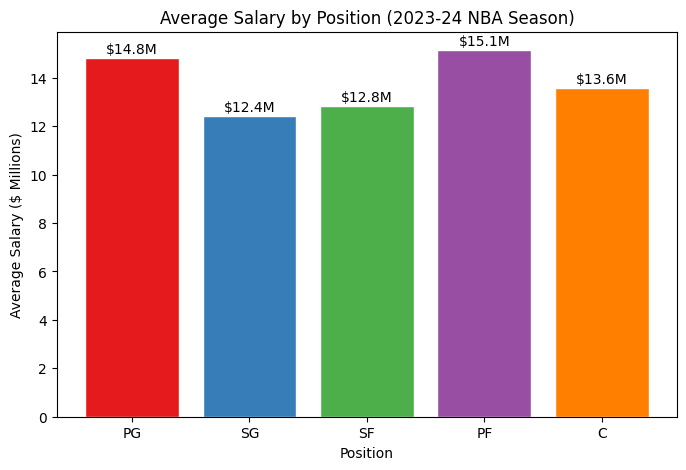

In [19]:
avg_salary_by_pos = merged_df.groupby('position')['salary_2023_24'].mean()

position_order = ['PG', 'SG', 'SF', 'PF', 'C']
avg_salary_by_pos = avg_salary_by_pos.reindex(position_order)

avg_salary_millions = avg_salary_by_pos / 1000000

plt.figure(figsize=(8, 5))
plt.bar(avg_salary_millions.index, avg_salary_millions.values,
        color=['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'],
        edgecolor='white')
plt.xlabel('Position')
plt.ylabel('Average Salary ($ Millions)')
plt.title('Average Salary by Position (2023-24 NBA Season)')

for i, val in enumerate(avg_salary_millions.values):
    plt.text(i, val + 0.2, '$' + str(round(val, 1)) + 'M', ha='center', fontsize=10)

plt.show()

Here we use .groupby() to calculate the average salary for each position and then reindex to put them in a logical order from PG to C. We divide by 1000000 to show millions and create a bar chart with a different color for each position. The for loop at the end adds the dollar amount as a text label on top of each bar so the exact values are visible. Power forwards and point guards earn the highest average salaries while shooting guards earn the least, though the differences are fairly small compared to the variation within positions.

# Top 10 Highest Paid Players

We want to see who the highest paid players are and whether their stats justify their salaries

In [20]:
top_10 = merged_df.nlargest(10, 'salary_2023_24')[['player_name', 'team', 'position',
                                                     'salary_2023_24', 'points_per_game',
                                                     'rebounds_per_game', 'assists_per_game']].copy()

top_10['salary_millions'] = round(top_10['salary_2023_24'] / 1000000, 1)

top_10[['player_name', 'team', 'position', 'salary_millions', 'points_per_game',
        'rebounds_per_game', 'assists_per_game']]

,player_name,team,position,salary_millions,points_per_game,rebounds_per_game,assists_per_game
10,Stephen Curry,GSW,PG,55.8,26.4,4.5,5.1
0,Joel Embiid,PHI,C,51.4,34.7,11.0,5.6
11,Nikola Jokić,DEN,C,51.4,26.4,12.4,9.0
6,Kevin Durant,PHO,PF,51.2,27.1,6.6,5.0
60,Bradley Beal,PHO,SG,50.2,18.2,4.4,5.0
5,Devin Booker,PHO,PG,49.2,27.1,4.5,6.9
23,Kawhi Leonard,LAC,SF,49.2,23.7,6.1,3.6
25,Jaylen Brown,BOS,SF,49.2,23.0,5.5,3.6
29,Paul George,LAC,PF,49.2,22.6,5.2,3.5
34,Karl-Anthony Towns,MIN,PF,49.2,21.8,8.3,3.0


Here we use .nlargest(10, 'salary_2023_24') to grab the 10 rows with the highest salary values and select only the columns we want to display. We add a salary_millions column by dividing the raw salary by 1000000 and rounding to one decimal place so it is easier to read. Looking at the results most of the top 10 have strong scoring numbers which aligns with our correlation findings, though Bradley Beal stands out as earning over 50 million while scoring below 20 points per game compared to his peers in this group.

# Export the Merged Dataset

For further analysis and the final report we save the merged dataset as a CSV file

In [21]:
merged_df.to_csv('nba_merged_stats_salaries_2023_24.csv', index=False)

print('File saved as nba_merged_stats_salaries_2023_24.csv')
print('Total rows saved:', len(merged_df))
print('Total columns saved:', len(merged_df.columns))

merged_df

File saved as nba_merged_stats_salaries_2023_24.csv
Total rows saved: 336
Total columns saved: 33


,Rk,player_name,age,team,position,games_played,GS,minutes_per_game,FG,FGA,...,rebounds_per_game,assists_per_game,steals_per_game,blocks_per_game,turnovers_per_game,PF,points_per_game,Awards,Player-additional,salary_2023_24
0,1.0,Joel Embiid,29.0,PHI,C,39.0,39.0,33.6,11.5,21.8,...,11.0,5.6,1.2,1.7,3.8,2.9,34.7,AS,embiijo01,51415938
1,2.0,Luka Dončić,24.0,DAL,PG,70.0,70.0,37.5,11.5,23.6,...,9.2,9.8,1.4,0.5,4.0,2.1,33.9,MVP-3CPOY-6ASNBA1,doncilu01,43031940
2,3.0,Giannis Antetokounmpo,29.0,MIL,PF,73.0,73.0,35.2,11.5,18.8,...,11.5,6.5,1.2,1.1,3.4,2.9,30.4,MVP-4DPOY-9CPOY-12ASNBA1,antetgi01,48787676
3,4.0,Shai Gilgeous-Alexander,25.0,OKC,PG,75.0,75.0,34.0,10.6,19.8,...,5.5,6.2,2.0,0.9,2.2,2.5,30.1,MVP-2DPOY-7CPOY-3ASNBA1,gilgesh01,35859950
4,5.0,Jalen Brunson,27.0,NYK,PG,77.0,77.0,35.4,10.3,21.4,...,3.6,6.7,0.9,0.2,2.4,1.9,28.7,MVP-5CPOY-5ASNBA2,brunsja01,24960001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,479.0,Cory Joseph,32.0,GSW,PG,26.0,0.0,11.4,0.9,2.5,...,1.2,1.6,0.2,0.1,0.5,1.0,2.4,NaN,josepco01,3303771
332,492.0,Andre Jackson Jr.,22.0,MIL,SG,57.0,8.0,10.0,0.9,1.8,...,2.0,0.9,0.3,0.1,0.5,1.6,2.2,NaN,jacksan01,1891857
333,504.0,Jericho Sims,25.0,NYK,C,45.0,11.0,13.0,0.8,1.2,...,3.3,0.6,0.2,0.4,0.4,1.0,2.0,NaN,simsje01,2092344
334,510.0,Taj Gibson,38.0,2TM,PF,20.0,1.0,10.2,0.8,1.9,...,1.9,0.6,0.2,0.4,0.3,1.6,1.7,NaN,gibsota01,2087519


Here we save the merged dataframe using .to_csv() with index=False so the row numbers are not written as a column in the file. We then print confirmation of how many rows and columns were saved and display the full dataframe so we can see exactly what the CSV file will look like. The dataset is now ready for our report and any additional analysis.